In [14]:
import pandas as pd
import numpy as np
from typing import List, Tuple, Dict
from dataclasses import dataclass
from enum import Enum
import random
import matplotlib.pyplot as plt

##### RULES:
Priority:

1) Volume Priority [Min(Ask_Vol, Sum(Bid_Vol WHERE Bid_Price >= Ask_Price))] 
2) Bid_Price Priority 
3) Bid_Time Priority (We are always last)

##### KEY AMBIGUITIES

Assumption: The order book is Dynamic (Random traders submit orders before us)

In [2]:
class OrderType(Enum):
    BUY = "BUY"
    SELL = "SELL"

class SubmitterType(Enum):
    MARKET_MAKER = "MM"  # Other traders
    US = "US"            # Our order

@dataclass
class Order:
    """Represents a single order in the book"""
    order_type: OrderType
    price: float
    volume: int
    timestamp: int  # Lower = earlier submission
    submitter: SubmitterType
    order_id: str
    
    def __repr__(self):
        submitter_str = "🔵" if self.submitter == SubmitterType.US else "⚪"
        return f"{submitter_str} {self.order_type.value}({self.volume}@{self.price})[T{self.timestamp}]"

@dataclass
class OrderBook:
    """Manages bids and asks for a tradable good"""
    good_name: str
    bids: List[Order]
    asks: List[Order]
    our_order: Order = None
    
    def add_our_order(self, order: Order):
        """Add our order (submitted last)"""
        self.our_order = order
        if order.order_type == OrderType.BUY:
            self.bids.append(order)
        else:
            self.asks.append(order)
    
    def get_all_bids_sorted(self) -> List[Order]:
        """Return bids sorted by price (desc) then time (asc) - price priority"""
        return sorted(self.bids, key=lambda x: (-x.price, x.timestamp))
    
    def get_all_asks_sorted(self) -> List[Order]:
        """Return asks sorted by price (asc) then time (asc) - price priority"""
        return sorted(self.asks, key=lambda x: (x.price, x.timestamp))
    
    def print_book(self):
        """Print the order book nicely"""
        print(f"\n{'='*80}")
        print(f"ORDER BOOK: {self.good_name}")
        print(f"{'='*80}")
        
        # Print asks (ascending)
        asks_sorted = sorted(self.asks, key=lambda x: -x.price)
        print(f"\nASK SIDE (sellers):")
        print(f"{'Price':<10} {'Volume':<15} {'Submitter':<15} {'Time'}")
        print(f"{'-'*50}")
        for ask in asks_sorted:
            sub = "US 🔵" if ask.submitter == SubmitterType.US else f"Trader#{ask.order_id}"
            print(f"{ask.price:<10} {ask.volume:<15,} {sub:<15} {ask.timestamp}")
        
        # Print bids (descending)
        bids_sorted = self.get_all_bids_sorted()
        print(f"\nBID SIDE (buyers):")
        print(f"{'Price':<10} {'Volume':<15} {'Submitter':<15} {'Time'}")
        print(f"{'-'*50}")
        for bid in bids_sorted:
            sub = "US 🔵" if bid.submitter == SubmitterType.US else f"Trader#{bid.order_id}"
            print(f"{bid.price:<10} {bid.volume:<15,} {sub:<15} {bid.timestamp}")

In [3]:
class DynamicMarketSimulator:
    """Simulates random trader order submissions before us"""
    
    def __init__(self, base_book: OrderBook, market_volatility: float = 0.5):
        """
        Args:
            base_book: The initial stale order book
            market_volatility: 0-1 scale, higher = more unpredictable market
        """
        self.base_book = base_book
        self.volatility = market_volatility
        self.new_orders = []
        self.order_counter = 0
    
    def _get_bid_range(self, current_max_bid: float, current_min_ask: float) -> Tuple[float, float]:
        """Calculate realistic range for new bids"""
        spread = current_min_ask - current_max_bid
        
        # New bids cluster around current max bid, some near midpoint
        lower = current_max_bid - (spread * 2 * self.volatility)
        upper = current_min_ask - (spread * 0.1)  # Not too close to asks
        
        return max(lower, current_max_bid * 0.8), upper
    
    def _get_ask_range(self, current_max_bid: float, current_min_ask: float) -> Tuple[float, float]:
        """Calculate realistic range for new asks"""
        spread = current_min_ask - current_max_bid
        
        # New asks cluster around current min ask, some near midpoint
        lower = current_max_bid + (spread * 0.1)  # Not too close to bids
        upper = current_min_ask + (spread * 2 * self.volatility)
        
        return lower, min(upper, current_min_ask * 1.2)
    
    def _get_volume(self, typical_volume: int) -> int:
        """Generate realistic order volume"""
        # Mix of small and large orders
        if random.random() < 0.3:  # 30% chance of large order
            return int(typical_volume * random.uniform(1.5, 3))
        elif random.random() < 0.5:  # 50% chance of medium order
            return int(typical_volume * random.uniform(0.5, 1.5))
        else:  # 20% chance of small order
            return int(typical_volume * random.uniform(0.1, 0.5))
    
    def generate_random_orders(self, num_new_orders: int = 10) -> List[Order]:
        """Generate random orders simulating other traders"""
        
        current_max_bid = max((o.price for o in self.base_book.bids), default=0)
        current_min_ask = min((o.price for o in self.base_book.asks), default=float('inf'))
        typical_volume = 5000
        
        current_timestamp = max(
            (o.timestamp for o in self.base_book.bids + self.base_book.asks),
            default=0
        )
        
        new_orders = []
        
        for i in range(num_new_orders):
            self.order_counter += 1
            timestamp = current_timestamp + i + 1  # Each new order comes later
            
            # 60% bids, 40% asks (market buys more than sells)
            is_bid = random.random() < 0.6
            
            if is_bid:
                bid_low, bid_high = self._get_bid_range(current_max_bid, current_min_ask)
                price = np.random.uniform(bid_low, bid_high)
                volume = self._get_volume(typical_volume)
                
                order = Order(
                    order_type=OrderType.BUY,
                    price=price,
                    volume=volume,
                    timestamp=timestamp,
                    submitter=SubmitterType.MARKET_MAKER,
                    order_id=f"BID_{self.order_counter}"
                )
            else:
                ask_low, ask_high = self._get_ask_range(current_max_bid, current_min_ask)
                price = np.random.uniform(ask_low, ask_high)
                volume = self._get_volume(typical_volume)
                
                order = Order(
                    order_type=OrderType.SELL,
                    price=price,
                    volume=volume,
                    timestamp=timestamp,
                    submitter=SubmitterType.MARKET_MAKER,
                    order_id=f"ASK_{self.order_counter}"
                )
            
            new_orders.append(order)
        
        return new_orders
    
    def apply_random_orders(self, new_orders: List[Order]):
        """Apply generated orders to the base book"""
        for order in new_orders:
            if order.order_type == OrderType.BUY:
                self.base_book.bids.append(order)
            else:
                self.base_book.asks.append(order)

In [4]:
class AuctionClearingEngine:
    """Simulates auction clearing with updated priority rules"""
    
    def __init__(self, order_book: OrderBook, buyback_price: float, fee: float = 0):
        self.order_book = order_book
        self.buyback_price = buyback_price
        self.fee = fee
        self.clearing_price = None
        self.total_volume = 0
        self.our_allocation = 0
        self.allocation_details = []
        self.execution_log = []
    
    def find_clearing_price(self) -> Tuple[float, int]:
        """
        Find clearing price that:
        1. Maximizes volume: min(ask_supply, sum(bid_vol WHERE bid_price >= ask_price))
        2. Ties broken by higher bid price
        3. Further ties broken by earlier bid submission time
        
        Returns: (clearing_price, max_volume)
        """
        bids = self.order_book.get_all_bids_sorted()
        asks = self.order_book.get_all_asks_sorted()
        
        # Try each unique price as potential clearing price
        potential_prices = set()
        for bid in bids:
            potential_prices.add(bid.price)
        for ask in asks:
            potential_prices.add(ask.price)
        
        # Sort prices descending to prioritize higher clearing prices on ties
        best_price = None
        best_volume = -1
        best_bid_priority = (float('inf'), float('inf'))  # (price desc, time asc)
        
        for price in sorted(potential_prices, reverse=True):
            # Volume = min(total asks at or below this price, total bids at or above this price)
            total_ask_volume = sum(o.volume for o in asks if o.price <= price)
            total_bid_volume = sum(o.volume for o in bids if o.price >= price)
            
            volume = min(total_ask_volume, total_bid_volume)
            
            if volume > best_volume:
                best_volume = volume
                best_price = price
            elif volume == best_volume and volume > 0:
                # Tie in volume: higher price wins
                if price > best_price:
                    best_price = price
        
        return best_price, best_volume
    
    def allocate_orders(self, clearing_price: float, total_volume: int):
        """
        Allocate orders at clearing price with proper priority:
        1. Bid Price Priority (higher price first)
        2. Bid Time Priority (earlier submission first)
        3. Ask Price Priority (lower price first)
        4. Ask Time Priority (earlier submission first)
        """
        self.allocation_details = []
        self.our_allocation = 0
        remaining_volume = total_volume
        
        # Get all executable orders
        bids = self.order_book.get_all_bids_sorted()
        asks = self.order_book.get_all_asks_sorted()
        
        executable_bids = [b for b in bids if b.price >= clearing_price]
        executable_asks = [a for a in asks if a.price <= clearing_price]
        
        # Allocate bids first (respecting priority)
        for bid in executable_bids:
            if remaining_volume <= 0:
                break
            
            allocation = min(bid.volume, remaining_volume)
            remaining_volume -= allocation
            
            is_ours = bid == self.order_book.our_order
            if is_ours:
                self.our_allocation = allocation
            
            self.allocation_details.append({
                'order': bid,
                'price': clearing_price,
                'allocated': allocation,
                'is_ours': is_ours,
                'side': 'BUY'
            })
            
            self.execution_log.append(
                f"BID: {bid.order_id} ({bid.submitter.value}) - "
                f"Allocated {allocation:,}/{bid.volume:,} @ {clearing_price}"
                f"{' ← US' if is_ours else ''}"
            )
    
    def calculate_profit(self) -> float:
        """Calculate our profit after auction and buyback"""
        if self.our_allocation == 0:
            return 0
        
        cost = self.clearing_price * self.our_allocation
        revenue = self.buyback_price * self.our_allocation - (self.fee * self.our_allocation)
        profit = revenue - cost
        return profit
    
    def run(self) -> Dict:
        """Execute the full auction"""
        clearing_price, total_volume = self.find_clearing_price()
        self.clearing_price = clearing_price
        self.total_volume = total_volume
        
        self.allocate_orders(clearing_price, total_volume)
        profit = self.calculate_profit()
        
        return {
            'clearing_price': clearing_price,
            'total_volume': total_volume,
            'our_allocation': self.our_allocation,
            'our_profit': profit,
            'cost': self.clearing_price * self.our_allocation if self.our_allocation > 0 else 0,
            'revenue': self.buyback_price * self.our_allocation - (self.fee * self.our_allocation) if self.our_allocation > 0 else 0,
        }

In [7]:
def create_dryland_flax_book():
    """Create Dryland Flax order book"""
    bids = [
        Order(OrderType.BUY, 30, 30000, timestamp=1, submitter=SubmitterType.MARKET_MAKER, order_id="BID_1"),
        Order(OrderType.BUY, 29, 5000, timestamp=2, submitter=SubmitterType.MARKET_MAKER, order_id="BID_2"),
        Order(OrderType.BUY, 28, 12000, timestamp=3, submitter=SubmitterType.MARKET_MAKER, order_id="BID_3"),
        Order(OrderType.BUY, 27, 28000, timestamp=4, submitter=SubmitterType.MARKET_MAKER, order_id="BID_4"),
    ]
    
    asks = [
        Order(OrderType.SELL, 28, 40000, timestamp=1, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_1"),
        Order(OrderType.SELL, 31, 20000, timestamp=2, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_2"),
        Order(OrderType.SELL, 32, 20000, timestamp=3, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_3"),
        Order(OrderType.SELL, 33, 30000, timestamp=4, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_4"),
    ]
    
    return OrderBook(
        good_name="Dryland Flax",
        bids=bids,
        asks=asks
    )

def create_ember_mushroom_book():
    """Create Ember Mushroom order book"""
    bids = [
        Order(OrderType.BUY, 20, 43000, timestamp=1, submitter=SubmitterType.MARKET_MAKER, order_id="BID_1"),
        Order(OrderType.BUY, 19, 17000, timestamp=2, submitter=SubmitterType.MARKET_MAKER, order_id="BID_2"),
        Order(OrderType.BUY, 18, 6000, timestamp=3, submitter=SubmitterType.MARKET_MAKER, order_id="BID_3"),
        Order(OrderType.BUY, 17, 5000, timestamp=4, submitter=SubmitterType.MARKET_MAKER, order_id="BID_4"),
        Order(OrderType.BUY, 16, 10000, timestamp=5, submitter=SubmitterType.MARKET_MAKER, order_id="BID_5"),
        Order(OrderType.BUY, 15, 5000, timestamp=6, submitter=SubmitterType.MARKET_MAKER, order_id="BID_6"),
        Order(OrderType.BUY, 14, 10000, timestamp=7, submitter=SubmitterType.MARKET_MAKER, order_id="BID_7"),
        Order(OrderType.BUY, 13, 7000, timestamp=8, submitter=SubmitterType.MARKET_MAKER, order_id="BID_8"),
    ]
    
    asks = [
        Order(OrderType.SELL, 12, 20000, timestamp=1, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_1"),
        Order(OrderType.SELL, 13, 25000, timestamp=2, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_2"),
        Order(OrderType.SELL, 14, 35000, timestamp=3, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_3"),
        Order(OrderType.SELL, 15, 6000, timestamp=4, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_4"),
        Order(OrderType.SELL, 16, 5000, timestamp=5, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_5"),
        Order(OrderType.SELL, 17, 0, timestamp=6, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_6"),
        Order(OrderType.SELL, 18, 10000, timestamp=7, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_7"),
        Order(OrderType.SELL, 19, 12000, timestamp=8, submitter=SubmitterType.MARKET_MAKER, order_id="ASK_8"),
    ]
    
    return OrderBook(
        good_name="Ember Mushroom",
        bids=bids,
        asks=asks
    )

print("\n Base order books created ✓")


 Base order books created ✓


In [8]:
class Strategy:
    """Represents a trading strategy"""
    
    def __init__(self, name: str, dryland_price: float, dryland_volume: int,
                 ember_price: float, ember_volume: int):
        self.name = name
        self.dryland_price = dryland_price
        self.dryland_volume = dryland_volume
        self.ember_price = ember_price
        self.ember_volume = ember_volume
        
        self.simulation_results = []  # Store results from multiple runs
    
    def run_single_auction(self, num_random_orders: int = 15, 
                          market_volatility: float = 0.5, verbose: bool = False) -> Dict:
        """Run a single auction scenario with random other traders"""
        
        # Create fresh books
        dryland_book = create_dryland_flax_book()
        ember_book = create_ember_mushroom_book()
        
        # Generate random orders
        dryland_sim = DynamicMarketSimulator(dryland_book, market_volatility)
        dryland_random = dryland_sim.generate_random_orders(num_random_orders)
        dryland_sim.apply_random_orders(dryland_random)
        
        ember_sim = DynamicMarketSimulator(ember_book, market_volatility)
        ember_random = ember_sim.generate_random_orders(num_random_orders)
        ember_sim.apply_random_orders(ember_random)
        
        # Add our orders (last submission)
        max_timestamp_dryland = max(o.timestamp for o in dryland_book.bids + dryland_book.asks)
        max_timestamp_ember = max(o.timestamp for o in ember_book.bids + ember_book.asks)
        
        dryland_our_order = Order(
            OrderType.BUY,
            self.dryland_price,
            self.dryland_volume,
            max_timestamp_dryland + 1,
            SubmitterType.US,
            "US_DRYLAND"
        )
        dryland_book.add_our_order(dryland_our_order)
        
        ember_our_order = Order(
            OrderType.BUY,
            self.ember_price,
            self.ember_volume,
            max_timestamp_ember + 1,
            SubmitterType.US,
            "US_EMBER"
        )
        ember_book.add_our_order(ember_our_order)
        
        # Run auctions
        dryland_engine = AuctionClearingEngine(dryland_book, buyback_price=30, fee=0)
        dryland_result = dryland_engine.run()
        
        ember_engine = AuctionClearingEngine(ember_book, buyback_price=20, fee=0.10)
        ember_result = ember_engine.run()
        
        return {
            'dryland': dryland_result,
            'ember': ember_result,
            'dryland_book': dryland_book,
            'ember_book': ember_book,
            'dryland_engine': dryland_engine,
            'ember_engine': ember_engine,
            'total_profit': dryland_result['our_profit'] + ember_result['our_profit'],
            'capital_needed': dryland_result['cost'] + ember_result['cost'],
        }
    
    def run_monte_carlo(self, num_simulations: int = 100, 
                       num_random_orders: int = 15,
                       market_volatility: float = 0.5):
        """Run multiple auction scenarios and collect statistics"""
        print(f"\n🎲 Running Monte Carlo for {self.name} ({num_simulations} simulations)...")
        
        self.simulation_results = []
        
        for i in range(num_simulations):
            result = self.run_single_auction(num_random_orders, market_volatility, verbose=False)
            self.simulation_results.append(result)
            
            if (i + 1) % 10 == 0:
                print(f"   Completed {i + 1}/{num_simulations}")
        
        print(f"✓ Monte Carlo complete")
    
    def get_statistics(self) -> Dict:
        """Calculate statistics from simulation results"""
        if not self.simulation_results:
            return {}
        
        profits = [r['total_profit'] for r in self.simulation_results]
        capital_needed = [r['capital_needed'] for r in self.simulation_results]
        
        dryland_allocations = [r['dryland']['our_allocation'] for r in self.simulation_results]
        ember_allocations = [r['ember']['our_allocation'] for r in self.simulation_results]
        
        dryland_prices = [r['dryland']['clearing_price'] for r in self.simulation_results]
        ember_prices = [r['ember']['clearing_price'] for r in self.simulation_results]
        
        return {
            'profit_mean': np.mean(profits),
            'profit_std': np.std(profits),
            'profit_min': np.min(profits),
            'profit_max': np.max(profits),
            'profit_median': np.median(profits),
            'win_rate': sum(1 for p in profits if p > 0) / len(profits) * 100,
            'avg_capital': np.mean(capital_needed),
            'dryland_alloc_mean': np.mean(dryland_allocations),
            'dryland_alloc_std': np.std(dryland_allocations),
            'ember_alloc_mean': np.mean(ember_allocations),
            'ember_alloc_std': np.std(ember_allocations),
            'dryland_price_mean': np.mean(dryland_prices),
            'dryland_price_std': np.std(dryland_prices),
            'ember_price_mean': np.mean(ember_prices),
            'ember_price_std': np.std(ember_prices),
        }
    
    def print_statistics(self):
        """Print detailed statistics"""
        stats = self.get_statistics()
        
        print(f"\n{'='*80}")
        print(f"STRATEGY: {self.name}")
        print(f"{'='*80}")
        
        print(f"\n📊 PROFIT DISTRIBUTION (from {len(self.simulation_results)} simulations):")
        print(f"  Mean:     {stats['profit_mean']:>12,.2f} XIRECs")
        print(f"  Median:   {stats['profit_median']:>12,.2f} XIRECs")
        print(f"  Std Dev:  {stats['profit_std']:>12,.2f} XIRECs")
        print(f"  Min:      {stats['profit_min']:>12,.2f} XIRECs")
        print(f"  Max:      {stats['profit_max']:>12,.2f} XIRECs")
        print(f"  Win Rate: {stats['win_rate']:>12,.1f}%")
        
        print(f"\n💰 CAPITAL ANALYSIS:")
        print(f"  Avg Capital Needed: {stats['avg_capital']:>12,.2f} XIRECs")
        
        avg_roi = (stats['profit_mean'] / max(stats['avg_capital'], 1)) * 100
        print(f"  Avg ROI: {avg_roi:>15,.1f}%")
        
        print(f"\n🌾 DRYLAND FLAX:")
        print(f"  Clearing Price: {stats['dryland_price_mean']:>10,.2f} ± {stats['dryland_price_std']:.2f}")
        print(f"  Our Allocation: {stats['dryland_alloc_mean']:>10,.0f} ± {stats['dryland_alloc_std']:.0f}")
        print(f"  Fill Rate: {(stats['dryland_alloc_mean']/self.dryland_volume)*100:>12,.1f}%")
        
        print(f"\n🍄 EMBER MUSHROOM:")
        print(f"  Clearing Price: {stats['ember_price_mean']:>10,.2f} ± {stats['ember_price_std']:.2f}")
        print(f"  Our Allocation: {stats['ember_alloc_mean']:>10,.0f} ± {stats['ember_alloc_std']:.0f}")
        print(f"  Fill Rate: {(stats['ember_alloc_mean']/self.ember_volume)*100:>12,.1f}%")


In [11]:
strategy_conservative = Strategy(
    name="CONSERVATIVE: Bid @ Market Prices (29, 16)",
    dryland_price=29,
    dryland_volume=5000,
    ember_price=16,
    ember_volume=10000
)

strategy_aggressive = Strategy(
    name="AGGRESSIVE: Bid High for Price Priority (99, 99)",
    dryland_price=99,
    dryland_volume=9999,
    ember_price=99,
    ember_volume=40000
)

strategy_middle = Strategy(
    name="MIDDLE GROUND: Balanced (95, 95)",
    dryland_price=95,
    dryland_volume=9999,
    ember_price=95,
    ember_volume=40000
)

# Run simulations
strategy_conservative.run_monte_carlo(num_simulations=100, num_random_orders=15, market_volatility=0.5)
strategy_aggressive.run_monte_carlo(num_simulations=100, num_random_orders=15, market_volatility=0.5)
strategy_middle.run_monte_carlo(num_simulations=100, num_random_orders=15, market_volatility=0.5)

# Print statistics
strategy_conservative.print_statistics()
strategy_aggressive.print_statistics()
strategy_middle.print_statistics()



🎲 Running Monte Carlo for CONSERVATIVE: Bid @ Market Prices (29, 16) (100 simulations)...
   Completed 10/100
   Completed 20/100
   Completed 30/100
   Completed 40/100
   Completed 50/100
   Completed 60/100
   Completed 70/100
   Completed 80/100
   Completed 90/100
   Completed 100/100
✓ Monte Carlo complete

🎲 Running Monte Carlo for AGGRESSIVE: Bid High for Price Priority (99, 99) (100 simulations)...
   Completed 10/100
   Completed 20/100
   Completed 30/100
   Completed 40/100
   Completed 50/100
   Completed 60/100
   Completed 70/100
   Completed 80/100
   Completed 90/100
   Completed 100/100
✓ Monte Carlo complete

🎲 Running Monte Carlo for MIDDLE GROUND: Balanced (95, 95) (100 simulations)...
   Completed 10/100
   Completed 20/100
   Completed 30/100
   Completed 40/100
   Completed 50/100
   Completed 60/100
   Completed 70/100
   Completed 80/100
   Completed 90/100
   Completed 100/100
✓ Monte Carlo complete

STRATEGY: CONSERVATIVE: Bid @ Market Prices (29, 16)

📊 PR

In [12]:
comparison_data = []

for strategy in [strategy_conservative, strategy_aggressive, strategy_middle]:
    stats = strategy.get_statistics()
    comparison_data.append({
        'Strategy': strategy.name,
        'Avg Profit': f"${stats['profit_mean']:,.0f}",
        'Std Dev': f"${stats['profit_std']:,.0f}",
        'Win Rate': f"{stats['win_rate']:.1f}%",
        'Avg Capital': f"${stats['avg_capital']:,.0f}",
        'Avg ROI': f"{(stats['profit_mean']/stats['avg_capital'])*100:.1f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))


                                        Strategy Avg Profit Std Dev Win Rate Avg Capital Avg ROI
      CONSERVATIVE: Bid @ Market Prices (29, 16)    $18,377 $21,302    63.0%    $103,871   17.7%
AGGRESSIVE: Bid High for Price Priority (99, 99)    $72,056 $42,094    97.0%  $1,023,914    7.0%
                MIDDLE GROUND: Balanced (95, 95)    $65,799 $40,408    98.0%  $1,030,171    6.4%


/tmp/ipykernel_37749/413930930.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Conservative', 'Aggressive', 'Middle'], patch_artist=True)



✓ Visualization saved to 'auction_analysis.png'


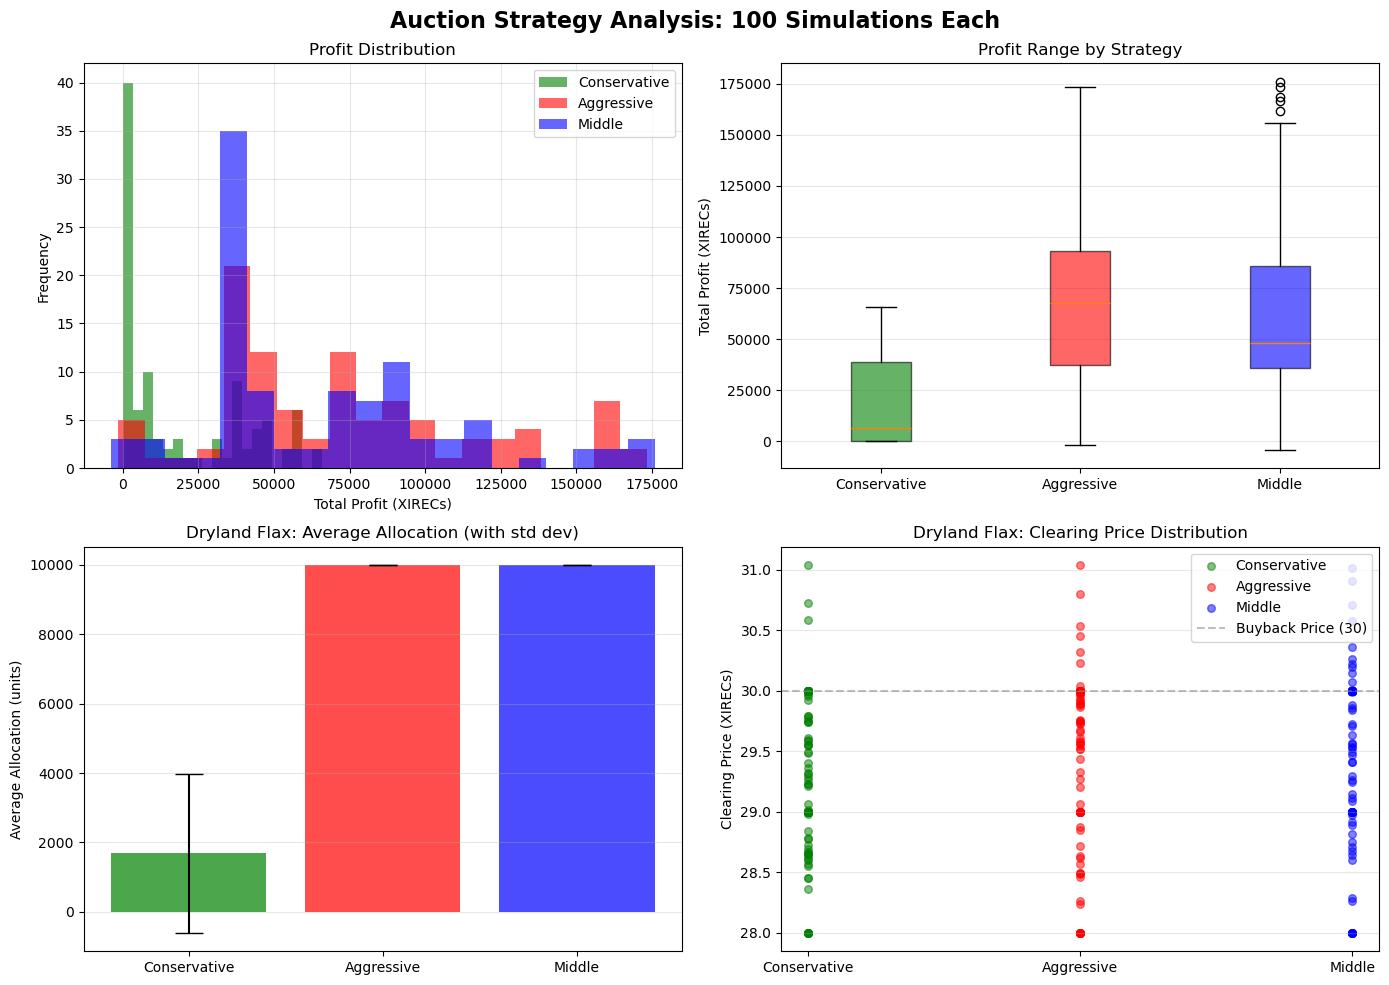

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Auction Strategy Analysis: 100 Simulations Each', fontsize=16, fontweight='bold')

# Profit distributions
ax = axes[0, 0]
profits_conservative = [r['total_profit'] for r in strategy_conservative.simulation_results]
profits_aggressive = [r['total_profit'] for r in strategy_aggressive.simulation_results]
profits_middle = [r['total_profit'] for r in strategy_middle.simulation_results]

ax.hist(profits_conservative, bins=20, alpha=0.6, label='Conservative', color='green')
ax.hist(profits_aggressive, bins=20, alpha=0.6, label='Aggressive', color='red')
ax.hist(profits_middle, bins=20, alpha=0.6, label='Middle', color='blue')
ax.set_xlabel('Total Profit (XIRECs)')
ax.set_ylabel('Frequency')
ax.set_title('Profit Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot
ax = axes[0, 1]
box_data = [profits_conservative, profits_aggressive, profits_middle]
bp = ax.boxplot(box_data, labels=['Conservative', 'Aggressive', 'Middle'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['green', 'red', 'blue']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Total Profit (XIRECs)')
ax.set_title('Profit Range by Strategy')
ax.grid(True, alpha=0.3, axis='y')

# Allocation comparison
ax = axes[1, 0]
dryland_alloc_cons = [r['dryland']['our_allocation'] for r in strategy_conservative.simulation_results]
dryland_alloc_agg = [r['dryland']['our_allocation'] for r in strategy_aggressive.simulation_results]
dryland_alloc_mid = [r['dryland']['our_allocation'] for r in strategy_middle.simulation_results]

x_pos = np.arange(3)
means = [np.mean(dryland_alloc_cons), np.mean(dryland_alloc_agg), np.mean(dryland_alloc_mid)]
stds = [np.std(dryland_alloc_cons), np.std(dryland_alloc_agg), np.std(dryland_alloc_mid)]

bars = ax.bar(x_pos, means, yerr=stds, capsize=10, alpha=0.7, 
              color=['green', 'red', 'blue'])
ax.set_ylabel('Average Allocation (units)')
ax.set_title('Dryland Flax: Average Allocation (with std dev)')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Conservative', 'Aggressive', 'Middle'])
ax.grid(True, alpha=0.3, axis='y')

# Clearing price distribution
ax = axes[1, 1]
dryland_price_cons = [r['dryland']['clearing_price'] for r in strategy_conservative.simulation_results]
dryland_price_agg = [r['dryland']['clearing_price'] for r in strategy_aggressive.simulation_results]
dryland_price_mid = [r['dryland']['clearing_price'] for r in strategy_middle.simulation_results]

ax.scatter([1]*len(dryland_price_cons), dryland_price_cons, alpha=0.5, s=30, label='Conservative', color='green')
ax.scatter([2]*len(dryland_price_agg), dryland_price_agg, alpha=0.5, s=30, label='Aggressive', color='red')
ax.scatter([3]*len(dryland_price_mid), dryland_price_mid, alpha=0.5, s=30, label='Middle', color='blue')

ax.axhline(y=30, color='gray', linestyle='--', alpha=0.5, label='Buyback Price (30)')
ax.set_ylabel('Clearing Price (XIRECs)')
ax.set_title('Dryland Flax: Clearing Price Distribution')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Conservative', 'Aggressive', 'Middle'])
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('auction_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved to 'auction_analysis.png'")
plt.show()

In [16]:
example_result = strategy_aggressive.run_single_auction(num_random_orders=12, market_volatility=0.5)

print("\n" + "="*80)
print("EXAMPLE: AGGRESSIVE STRATEGY AUCTION")
print("="*80)

# Show books
example_result['dryland_book'].print_book()
example_result['ember_book'].print_book()

# Show execution results
print(f"\n{'='*80}")
print("CLEARING RESULTS")
print(f"{'='*80}")

print(f"\n🌾 DRYLAND FLAX:")
print(f"  Clearing Price: {example_result['dryland']['clearing_price']}")
print(f"  Total Volume: {example_result['dryland']['total_volume']:,}")
print(f"  Our Allocation: {example_result['dryland']['our_allocation']:,}")
print(f"  Our Cost: {example_result['dryland']['cost']:,.2f}")
print(f"  Our Revenue: {example_result['dryland']['revenue']:,.2f}")
print(f"  Our Profit: {example_result['dryland']['our_profit']:,.2f}")

print(f"\n🍄 EMBER MUSHROOM:")
print(f"  Clearing Price: {example_result['ember']['clearing_price']}")
print(f"  Total Volume: {example_result['ember']['total_volume']:,}")
print(f"  Our Allocation: {example_result['ember']['our_allocation']:,}")
print(f"  Our Cost: {example_result['ember']['cost']:,.2f}")
print(f"  Our Revenue: {example_result['ember']['revenue']:,.2f}")
print(f"  Our Profit: {example_result['ember']['our_profit']:,.2f}")

print(f"\n💰 TOTAL:")
print(f"  Total Capital: {example_result['capital_needed']:,.2f}")
print(f"  Total Profit: {example_result['total_profit']:,.2f}")
print(f"  ROI: {(example_result['total_profit']/example_result['capital_needed'])*100:.1f}%")


EXAMPLE: AGGRESSIVE STRATEGY AUCTION

ORDER BOOK: Dryland Flax

ASK SIDE (sellers):
Price      Volume          Submitter       Time
--------------------------------------------------
33         30,000          Trader#ASK_4    4
32         20,000          Trader#ASK_3    3
31         20,000          Trader#ASK_2    2
29.590764126323496 512             Trader#ASK_2    6
29.580339800756025 507             Trader#ASK_9    13
29.269211175225507 839             Trader#ASK_4    8
28.761449717103854 6,967           Trader#ASK_12   16
28         40,000          Trader#ASK_1    1
27.775436068076242 6,288           Trader#ASK_5    9
27.454812390990185 759             Trader#ASK_7    11
26.737326168410107 1,615           Trader#ASK_10   14

BID SIDE (buyers):
Price      Volume          Submitter       Time
--------------------------------------------------
99         9,999           US 🔵            17
31.93512648171628 4,648           Trader#BID_11   15
31.10369899725296 13,663          Trader#BI